# Hourly bus passenger loading profile

This notebook converts CSO-style daily passenger-flow percentages by broad time segment into an hourly profile for BEB passenger-loading modelling.

Key update: the hourly conversion now accounts for the fact that most buses mainly operate within a service window, rather than evenly spreading early/late time-bin demand across inactive midnight hours.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# The notebook is inside notebook/
# data/ is at the same level as notebook/
csv_path = Path("../data/raw/TOA19.20260615112451.csv")

df_raw = pd.read_csv(csv_path)

df = df_raw.rename(columns={
    "City Services": "city",
    "Time of Day": "time_segment",
    "VALUE": "daily_flow_percent"
})[["Year", "city", "time_segment", "daily_flow_percent"]].copy()

df.head()

,Year,city,time_segment,daily_flow_percent
0,2012,Cork,00:00 - 06:59,0.3
1,2012,Cork,07:00 - 07:59,4.9
2,2012,Cork,08:00 - 08:59,7.3
3,2012,Cork,09:00 - 09:59,5.7
4,2012,Cork,10:00 - 12:59,20.3


## 1. Filter the study period

We use 2013–2023 because this is the period selected for the current BEB passenger-loading profile. The `"All times"` category is removed because it is the daily total, not a time segment.


In [2]:
start_year = 2013
end_year = 2023

df_period = df[
    (df["Year"].between(start_year, end_year)) &
    (df["time_segment"] != "All times")
].copy()

df_period.head()

,Year,city,time_segment,daily_flow_percent
60,2013,Cork,00:00 - 06:59,1.0
61,2013,Cork,07:00 - 07:59,0.4
62,2013,Cork,08:00 - 08:59,5.1
63,2013,Cork,09:00 - 09:59,7.4
64,2013,Cork,10:00 - 12:59,18.6


## 2. Parse original time segments

The original data contains broad time bins, such as `10:00-12:59`. These are cumulative passenger-flow percentages across the whole bin.

We keep the original segment information for checking, but the hourly conversion below uses minute-level overlap with the service window.


In [3]:
def time_to_minutes(t: str) -> int:
    """
    Convert HH:MM into minutes after midnight.
    Example: '05:30' -> 330.
    """
    h, m = map(int, t.strip().split(":")[:2])
    return h * 60 + m


def parse_time_segment_to_minutes(segment: str):
    """
    Convert a time segment like '10:00 - 12:59'
    into start and end minutes.

    The end time is treated as inclusive.
    Therefore, 12:59 becomes 13:00.
    """
    start, end = [x.strip() for x in segment.split("-")]

    start_min = time_to_minutes(start)
    end_min = time_to_minutes(end) + 1

    return start_min, end_min


def parse_time_segment(segment: str) -> pd.Series:
    """
    Keep a simple hour-level summary of the original time segment.
    This is mainly useful for checking the original data structure.
    """
    start_min, end_min = parse_time_segment_to_minutes(segment)

    start_hour = start_min // 60
    end_hour = (end_min - 1) // 60
    duration_hours = (end_min - start_min) / 60

    return pd.Series({
        "start_min": start_min,
        "end_min": end_min,
        "start_hour": start_hour,
        "end_hour": end_hour,
        "duration_hours": duration_hours
    })


time_info = df_period["time_segment"].apply(parse_time_segment)
df_segments = pd.concat([df_period, time_info], axis=1)

df_segments.head()

,Year,city,time_segment,daily_flow_percent,start_min,end_min,start_hour,end_hour,duration_hours
60,2013,Cork,00:00 - 06:59,1.0,0.0,420.0,0.0,6.0,7.0
61,2013,Cork,07:00 - 07:59,0.4,420.0,480.0,7.0,7.0,1.0
62,2013,Cork,08:00 - 08:59,5.1,480.0,540.0,8.0,8.0,1.0
63,2013,Cork,09:00 - 09:59,7.4,540.0,600.0,9.0,9.0,1.0
64,2013,Cork,10:00 - 12:59,18.6,600.0,780.0,10.0,12.0,3.0


## 3. Set the bus operating window

The old method divided each broad time-bin percentage evenly by clock hours. This underestimates passenger loading in the early morning because a bin like `00:00-06:59` is spread across seven hours, even though buses may only start around 05:30 or 06:00.

Here we preserve each original time-bin total, but allocate it only to the part of the bin that overlaps with active bus operating time.

You can adjust these two parameters later if you want a different assumption.


In [4]:
# Main operating-window assumption.
# Change to 6.0 if you want a stricter 06:00 start.
# Change to 23.5 if you want to allow services until around 23:30.
service_start_hour = 5.5   # 05:30
service_end_hour = 23.0    # 23:00

service_start_min = int(service_start_hour * 60)
service_end_min = int(service_end_hour * 60)

print(f"Service window: {service_start_min // 60:02d}:{service_start_min % 60:02d} "
      f"to {service_end_min // 60:02d}:{service_end_min % 60:02d}")

Service window: 05:30 to 23:00


## 4. Convert original segments into operating-hour-adjusted hourly loading

Two hourly measures are created:

- `allocated_hourly_flow_percent`: preserves the original segment total and splits it by active minutes in each hour.
- `hourly_loading_intensity`: gives the same per-active-hour loading intensity within each original segment. This is the better column for passenger loading in the BEB model.

For the final profile, we use `hourly_loading_intensity` and keep the downstream column name as `avg_hourly_flow_percent`, because `gtfs_to_segments.py` expects that column.


In [5]:
def hour_overlap_minutes(
    segment_start_min,
    segment_end_min,
    hour,
    service_start_min,
    service_end_min
):
    """
    Calculate how many active operating minutes of one clock hour overlap
    with the original time segment and the assumed service window.
    """
    hour_start = hour * 60
    hour_end = (hour + 1) * 60

    overlap_start = max(segment_start_min, hour_start, service_start_min)
    overlap_end = min(segment_end_min, hour_end, service_end_min)

    return max(0, overlap_end - overlap_start)


expanded_rows = []

for _, row in df_segments.iterrows():
    segment_start_min = int(row["start_min"])
    segment_end_min = int(row["end_min"])

    overlaps = []

    for hour in range(24):
        active_minutes = hour_overlap_minutes(
            segment_start_min,
            segment_end_min,
            hour,
            service_start_min,
            service_end_min
        )

        if active_minutes > 0:
            overlaps.append((hour, active_minutes))

    total_active_minutes = sum(minutes for _, minutes in overlaps)

    # If the original segment does not overlap the assumed service window,
    # no passenger-loading row is created for that segment.
    if total_active_minutes == 0:
        continue

    active_hours = total_active_minutes / 60

    for hour, active_minutes in overlaps:
        expanded_rows.append({
            "year": int(row["Year"]),
            "city": row["city"],
            "hour": hour,
            "time_segment": row["time_segment"],
            "daily_flow_percent": row["daily_flow_percent"],
            "active_minutes_in_hour": active_minutes,
            "segment_active_minutes": total_active_minutes,

            # Preserves the total percentage of the original time bin.
            "allocated_hourly_flow_percent": (
                row["daily_flow_percent"] * active_minutes / total_active_minutes
            ),

            # Better for passenger loading because it represents
            # load intensity during active service time.
            "hourly_loading_intensity": (
                row["daily_flow_percent"] / active_hours
            )
        })

df_hourly_by_year = pd.DataFrame(expanded_rows)

df_hourly_by_year.head(30)

,year,city,hour,time_segment,daily_flow_percent,active_minutes_in_hour,segment_active_minutes,allocated_hourly_flow_percent,hourly_loading_intensity
0,2013,Cork,5,00:00 - 06:59,1.0,30,90,0.333333,0.666667
1,2013,Cork,6,00:00 - 06:59,1.0,60,90,0.666667,0.666667
2,2013,Cork,7,07:00 - 07:59,0.4,60,60,0.400000,0.400000
3,2013,Cork,8,08:00 - 08:59,5.1,60,60,5.100000,5.100000
4,2013,Cork,9,09:00 - 09:59,7.4,60,60,7.400000,7.400000
5,2013,Cork,10,10:00 - 12:59,18.6,60,180,6.200000,6.200000
6,2013,Cork,11,10:00 - 12:59,18.6,60,180,6.200000,6.200000
7,2013,Cork,12,10:00 - 12:59,18.6,60,180,6.200000,6.200000
8,2013,Cork,13,13:00 - 15:59,23.7,60,180,7.900000,7.900000
9,2013,Cork,14,13:00 - 15:59,23.7,60,180,7.900000,7.900000


## 5. Build the final hourly loading profile

The final long table has 24 rows per city, one for each clock hour. Inactive hours are kept with `0.0` loading so downstream code still receives a complete 0–23 hourly profile.


In [6]:
df_hourly_avg_active = (
    df_hourly_by_year
    .groupby(["city", "hour"], as_index=False)
    .agg(
        avg_hourly_flow_percent=("hourly_loading_intensity", "mean"),
        years_available=("hourly_loading_intensity", "count")
    )
)

# Create a complete city-hour grid so every city has hours 0-23.
all_cities = sorted(df_period["city"].dropna().unique())
all_hours = list(range(24))

complete_grid = pd.MultiIndex.from_product(
    [all_cities, all_hours],
    names=["city", "hour"]
).to_frame(index=False)

df_hourly_avg = (
    complete_grid
    .merge(df_hourly_avg_active, on=["city", "hour"], how="left")
    .fillna({
        "avg_hourly_flow_percent": 0.0,
        "years_available": 0
    })
    .sort_values(["city", "hour"])
    .reset_index(drop=True)
)

df_hourly_avg["years_available"] = df_hourly_avg["years_available"].astype(int)

df_hourly_avg

,city,hour,avg_hourly_flow_percent,years_available
0,Cork,0,0.000000,0
1,Cork,1,0.000000,0
2,Cork,2,0.000000,0
3,Cork,3,0.000000,0
4,Cork,4,0.000000,0
...,...,...,...,...
115,Waterford,19,1.490476,7
116,Waterford,20,1.490476,7
117,Waterford,21,1.490476,7
118,Waterford,22,0.900000,7


## 6. Create the pivot version for visualisation

The pivot table contains the same information as the long table, but cities are shown as columns. This format is easier for plotting and quick comparison.


In [7]:
df_hourly_pivot = (
    df_hourly_avg
    .pivot(index="hour", columns="city", values="avg_hourly_flow_percent")
    .reset_index()
)

df_hourly_pivot

city,hour,Cork,Dublin,Galway,Limerick,Waterford
0,0,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,0.000000,0.000000,0.000000
3,3,0.000000,0.000000,0.000000,0.000000,0.000000
4,4,0.000000,0.000000,0.000000,0.000000,0.000000
5,5,1.112727,2.648485,0.972121,0.332121,0.057143
6,6,1.112727,2.648485,0.972121,0.332121,0.057143
7,7,4.884545,7.127273,3.905455,3.674545,1.400000
8,8,6.311818,7.900000,6.406364,6.344545,6.814286
9,9,5.751818,5.263636,5.783636,6.309091,7.828571


## 7. Visualise the operating-hour-adjusted profile

This plot now reflects passenger-loading intensity during the assumed operating window, not a simple even split across all clock hours.


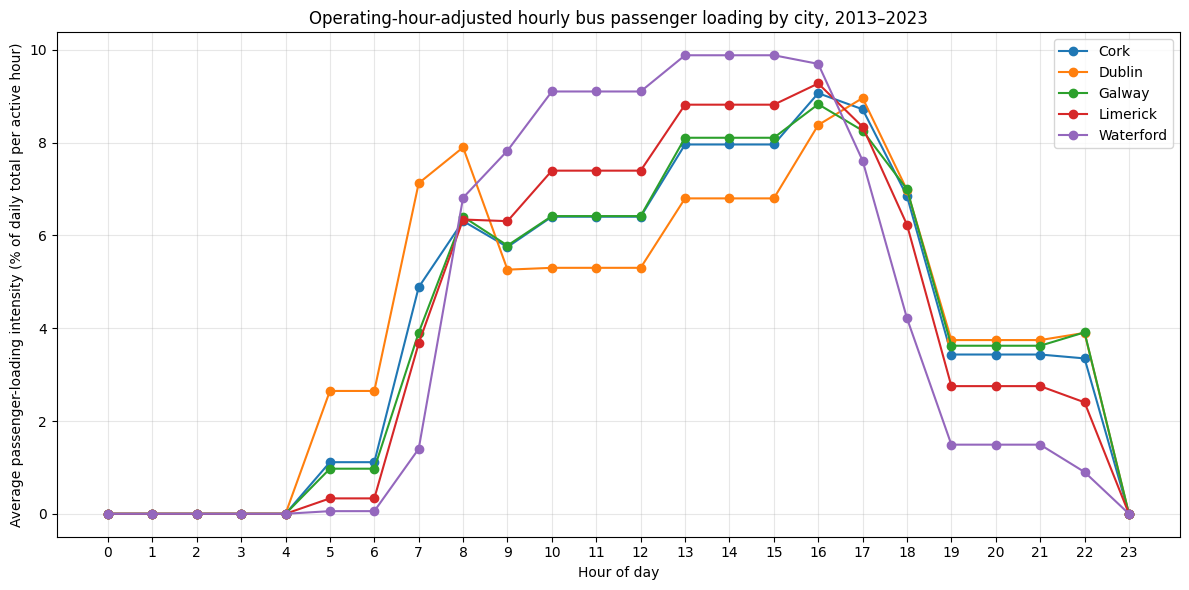

In [8]:
plt.figure(figsize=(12, 6))

for city in df_hourly_pivot.columns.drop("hour"):
    plt.plot(
        df_hourly_pivot["hour"],
        df_hourly_pivot[city],
        marker="o",
        label=city
    )

plt.title("Operating-hour-adjusted hourly bus passenger loading by city, 2013–2023")
plt.xlabel("Hour of day")
plt.ylabel("Average passenger-loading intensity (% of daily total per active hour)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Save only the final two tables

Because this notebook is inside the `notebook/` folder, the processed output path is:

```text
../data/processed/
```

These are the two files to use later in the BEB passenger-loading model.


In [9]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

long_output_path = processed_dir / "bus_hourly_loading_profile_2013_2023_long.csv"
pivot_output_path = processed_dir / "bus_hourly_loading_profile_2013_2023_pivot.csv"

df_hourly_avg.to_csv(long_output_path, index=False)
df_hourly_pivot.to_csv(pivot_output_path, index=False)

print(f"Saved: {long_output_path}")
print(f"Saved: {pivot_output_path}")

Saved: ..\data\processed\bus_hourly_loading_profile_2013_2023_long.csv
Saved: ..\data\processed\bus_hourly_loading_profile_2013_2023_pivot.csv
